# Verification — `MIL_CREDA` against `research-concept-r14.md`

Executed report, not the source of truth. Every mathematical claim lives as a
test under `tests/`; this page runs them and shows the evidence. Existence of
this file proves nothing — `verify` reads whether its cells actually ran.

Re-run headlessly from the repository root:

```
.venv/bin/jupyter nbconvert --to notebook --execute --inplace \
  MIL-CREDA/Notebooks/verification.ipynb
```

In [1]:
import ast
import sys
from pathlib import Path

import numpy as np

ROOT = Path.cwd().parents[1]  # <repo>/MIL-CREDA/Notebooks -> <repo>
sys.path.insert(0, str(ROOT / "src"))
rng = np.random.default_rng(20260810)

# Which revision each module was written against, read statically.
for file in sorted((ROOT / "src" / "MIL_CREDA").rglob("*.py")):
    if file.name == "__init__.py":
        continue
    for node in ast.parse(file.read_text()).body:
        if any(getattr(t, "id", None) == "__provenance__" for t in getattr(node, "targets", [])):
            p = ast.literal_eval(node.value)
            print(f"{file.name:<18} {p['revision']:<26} eqs {','.join(p['equations'])}")

attention.py       research-concept-r14.md    eqs 14,15,16
bag_kernel.py      research-concept-r14.md    eqs 20,21
conditional.py     research-concept-r14.md    eqs 23,25,26,27
confidence.py      research-concept-r14.md    eqs 22,24
global_term.py     research-concept-r14.md    eqs 32,33,34,35,36,37
kernels.py         research-concept-r14.md    eqs 2,19
local_term.py      research-concept-r14.md    eqs 28,29,30,31,38
objective.py       research-concept-r14.md    eqs 18,39
renyi.py           research-concept-r14.md    eqs 7,8,9,10,11,12


## Levels 1, 2, 4 and 5 — the suite

A red cell here means the implementation does not match what the proposal
claims. Do not edit the assertion to make it pass.

In [2]:
import pytest

code = pytest.main(["-q", str(ROOT / "tests"), "--rootdir", str(ROOT)])
assert code == 0, f"test suite failed (pytest exit code {code})"

.

.

.

.

.

...

.

.

.

                               [100%]


42 passed in 0.85s


## Level 3 — synthetic evidence

Deterministic, fixed seed, ground truth known by construction. State the
expected behaviour before looking at the output.

target bags measured: 905   max d_j^2 = 1.999267
declared normalizer /4 -> max l_loc,j = 0.499817
proposed normalizer /2 -> max l_loc,j = 0.999633


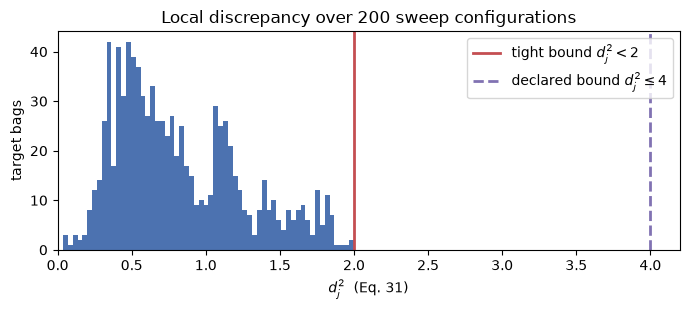

In [3]:
# Level 3 evidence: the audited constant, drawn from the same sweep the tests use.
import sys
sys.path.insert(0, str(ROOT / "tests"))
import matplotlib.pyplot as plt
from sweep import sweep

distances = np.concatenate([c["squared_distances"] for c in sweep() if c["squared_distances"].size])
print(f"target bags measured: {distances.size}   max d_j^2 = {distances.max():.6f}")
print(f"declared normalizer /4 -> max l_loc,j = {distances.max()/4:.6f}")
print(f"proposed normalizer /2 -> max l_loc,j = {distances.max()/2:.6f}")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(distances, bins=60, color="#4c72b0")
ax.axvline(2.0, color="#c44e52", lw=2, label="tight bound $d_j^2 < 2$")
ax.axvline(4.0, color="#8172b2", lw=2, ls="--", label="declared bound $d_j^2 \\leq 4$")
ax.set_xlim(0, 4.2)
ax.set_xlabel("$d_j^2$  (Eq. 31)")
ax.set_ylabel("target bags")
ax.set_title("Local discrepancy over 200 sweep configurations")
ax.legend()
fig.tight_layout()
fig.savefig(ROOT / "MIL-CREDA" / "Results" / "local_distance_bound.png", dpi=150)
plt.show()
